***missing numerical data imputation***

In [20]:
import pandas as pd 
df=pd.read_csv('titanic_toy.csv')

In [21]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [22]:
from sklearn.model_selection import train_test_split
x=df.iloc[:,0:3]
y=df.iloc[:,-1]

x_train,x_test,y_train,y_test=train_test_split(x,y)
x_train

,Age,Fare,Family
380,42.0,227.5250,0
614,35.0,8.0500,0
830,15.0,14.4542,1
151,22.0,66.6000,1
56,21.0,10.5000,0
...,...,...,...
466,NaN,NaN,0
499,24.0,7.7958,0
602,NaN,42.4000,0
446,13.0,19.5000,1


***filling of missing value by mean median using pandas***

In [23]:
x_train['new_Age_mean']=x_train['Age'].fillna(x_train['Age'].mean())
x_train['new_Age_median']=x_train['Age'].fillna(x_train['Age'].median())

x_train['new_Fare_mean']=x_train['Fare'].fillna(x_train['Fare'].mean())
x_train['new_Fare_median']=x_train['Fare'].fillna(x_train['Fare'].median())


In [33]:
x_train

,Age,Fare,Family,new_Age_mean,new_Age_median,new_Fare_mean,new_Fare_median
380,42.0,227.5250,0,42.000000,42.0,227.525000,227.5250
614,35.0,8.0500,0,35.000000,35.0,8.050000,8.0500
830,15.0,14.4542,1,15.000000,15.0,14.454200,14.4542
151,22.0,66.6000,1,22.000000,22.0,66.600000,66.6000
56,21.0,10.5000,0,21.000000,21.0,10.500000,10.5000
...,...,...,...,...,...,...,...
466,NaN,NaN,0,29.689667,28.0,32.520826,14.5000
499,24.0,7.7958,0,24.000000,24.0,7.795800,7.7958
602,NaN,42.4000,0,29.689667,28.0,42.400000,42.4000
446,13.0,19.5000,1,13.000000,13.0,19.500000,19.5000


In [34]:
def variance (y) :
    print('age variance before ',y['Age'].var())
    print('age variance after mean ',y['new_Age_mean'].var())
    print('age variance after mean ',y['new_Age_median'].var())
    
    print('fare variance before ',y['Fare'].var())
    print('age variance after mean ',y['new_Fare_mean'].var())
    print('age variance after mean ',y['new_Fare_median'].var())
    
    
    


In [35]:
variance(x_train)

age variance before  206.20567447124304
age variance after mean  166.63397082458772
age variance after mean  167.07686860731312
fare variance before  2264.3156193843447
age variance after mean  2148.893233988441
age variance after mean  2164.604648318454


In [50]:
import matplotlib.pyplot as plp
import seaborn as sns 

In [53]:
def draw(y) :
    fig, (ax1,ax2) =plp.subplots(1,2,figsize=(12,5))
    ax1.set_title('age')
    sns.kdeplot(y['Age'],  ax= ax1)
    sns.kdeplot(y['new_Age_mean'],  ax= ax1)
    sns.kdeplot(y['new_Age_median'],  ax= ax1)
    
    ax2.set_title('Fare')
    sns.kdeplot(y['Age'], ax= ax2)
    sns.kdeplot(y['new_Age_mean'], ax= ax2)
    sns.kdeplot(y['new_Age_median'],ax= ax2)
    
   



In [60]:
def draw(y,col,col1) :
    fig, (ax1,ax2) =plp.subplots(1,2,figsize=(12,5))
    ax1.set_title(col)
    sns.kdeplot(y[col],  ax= ax1)
    sns.kdeplot(y[f'new_{col}_mean'],  ax= ax1)
    sns.kdeplot(y[f'new_{col}_median'],  ax= ax1)
    
    ax2.set_title(col1)
    sns.kdeplot(y[col1], ax= ax2)
    sns.kdeplot(y[f'new_{col1}_mean'], ax= ax2)
    sns.kdeplot(y[f'new_{col1}_median'],ax= ax2)
    
   


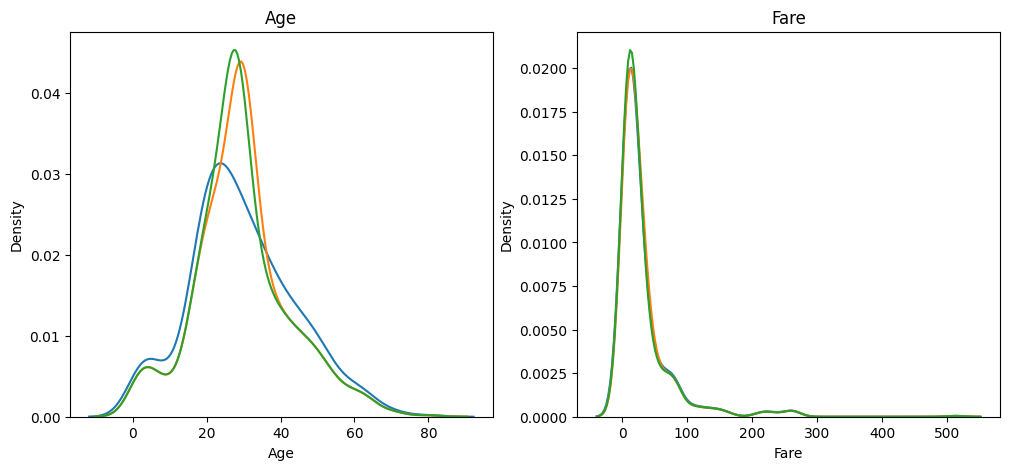

In [61]:
draw(x_train,'Age','Fare')

In [62]:
x_train.cov()


,Age,Fare,Family,new_Age_mean,new_Age_median,new_Fare_mean,new_Fare_median
Age,206.205674,86.836385,-6.254334,206.205674,206.205674,81.857200,79.617145
Fare,86.836385,2264.315619,18.912896,69.701470,73.071326,2264.315619,2264.315619
Family,-6.254334,18.912896,2.671422,-5.054102,-5.021883,17.948821,18.166742
new_Age_mean,206.205674,69.701470,-5.054102,166.633971,166.633971,66.148472,64.338293
new_Age_median,206.205674,73.071326,-5.021883,166.633971,167.076869,69.346551,67.467212
new_Fare_mean,81.857200,2264.315619,17.948821,66.148472,69.346551,2148.893234,2148.893234
new_Fare_median,79.617145,2264.315619,18.166742,64.338293,67.467212,2148.893234,2164.604648


In [64]:
x_train.corr()

,Age,Fare,Family,new_Age_mean,new_Age_median,new_Fare_mean,new_Fare_median
Age,1.000000,0.117678,-0.287688,1.000000,1.000000,0.115796,0.112140
Fare,0.117678,1.000000,0.240088,0.111911,0.117193,1.000000,1.000000
Family,-0.287688,0.240088,1.000000,-0.239547,-0.237704,0.236896,0.238900
new_Age_mean,1.000000,0.111911,-0.239547,1.000000,0.998674,0.110543,0.107127
new_Age_median,1.000000,0.117193,-0.237704,0.998674,1.000000,0.115734,0.112188
new_Fare_mean,0.115796,1.000000,0.236896,0.110543,0.115734,1.000000,0.996364
new_Fare_median,0.112140,1.000000,0.238900,0.107127,0.112188,0.996364,1.000000


<Axes: ylabel='new_Age_median'>

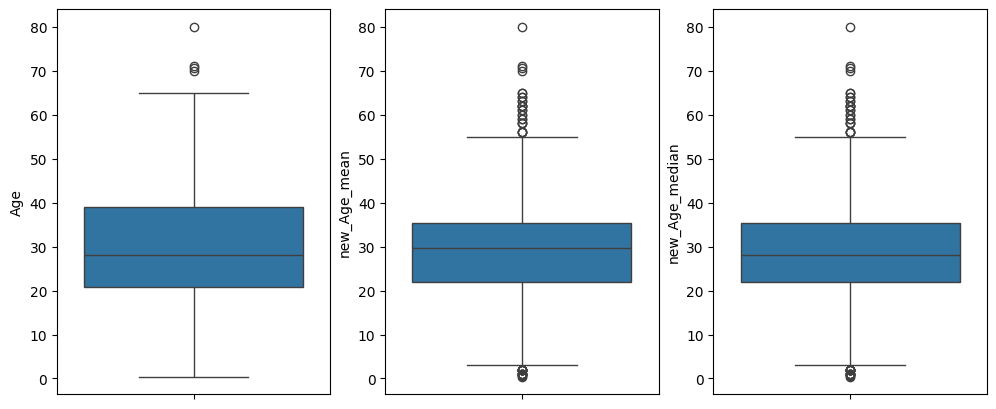

In [84]:

fig, (ax1,ax2,ax3) =plp.subplots(1,3,figsize=(12,5))

sns.boxplot(x_train['Age'],ax=ax1)
sns.boxplot(x_train['new_Age_mean'],ax=ax2)
sns.boxplot(x_train['new_Age_median'],ax=ax3)


<Axes: ylabel='new_Fare_median'>

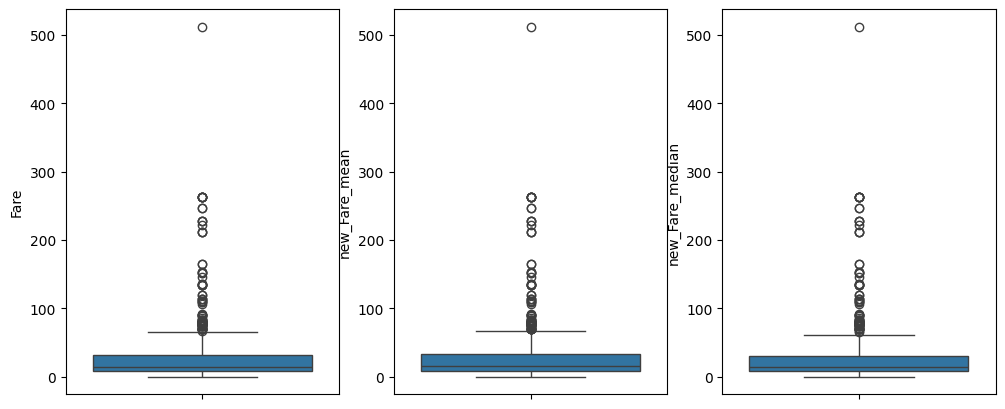

In [82]:
fig, (ax1,ax2,ax3) =plp.subplots(1,3,figsize=(12,5))

sns.boxplot(x_train['Fare'],ax=ax1)
sns.boxplot(x_train['new_Fare_mean'],ax=ax2)
sns.boxplot(x_train['new_Fare_median'],ax=ax3)


***use of scikit learn class to fill missing value by mean median ***


In [87]:
x_train=x_train[['Age','Fare','Family']]

In [88]:
x_train

,Age,Fare,Family
380,42.0,227.5250,0
614,35.0,8.0500,0
830,15.0,14.4542,1
151,22.0,66.6000,1
56,21.0,10.5000,0
...,...,...,...
466,NaN,NaN,0
499,24.0,7.7958,0
602,NaN,42.4000,0
446,13.0,19.5000,1


In [93]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
trf= ColumnTransformer(
    transformers=[
   ('trf1',SimpleImputer(strategy='mean'),['Age']),
   ('trf2',SimpleImputer(strategy='median'),['Fare'])
        
    
    
    
],remainder='passthrough')



In [94]:
x_train_impute=trf.fit_transform(x_train)
x_test_impute=trf.fit_transform(x_test)

In [98]:
trf.named_transformers_['trf1'].statistics_

array([29.72844828])